#  Strojno Učenje in Napredna Analiza

## Glavni cilji: Odgovoriti na RV3, RV4 in RV5

| Koda | Raziskovalno Vprašanje | Metoda |
|------|------------------------|--------|
| **RV3** | Ali se glasba lahko razdeli v skupine? | K-Means klasteriranje |
| **RV4** | Kateri zvočni profili so povezani s popularnostjo? | Korelacije, Feature Importance |
| **RV5** | Ali lahko napovemo žanr/popularnost? | Random Forest, GBM, Ridge, Lasso |

### Napredne tehnike v tem notebooku:
1. **Regresijski modeli:** Napovedovanje popularnosti (0-100)
2. **Klasifikacijski modeli:** Napovedovanje žanra
3. **Klasteriranje:** K-Means z Elbow in Silhouette metodami
4. **Monte Carlo simulacija:** Testiranje robustnosti
5. **Sensitivity Analysis:** Občutljivost na posamezne značilnosti

---

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_palette('husl')

print(" Knjižnice uvožene!")

✅ Knjižnice uvožene!


In [ ]:


print(" NALAGANJE PODATKOV")
print("=" * 60)

# 1. Glavni dataset z audio features
df_main = pd.read_csv('../data/dataset.csv')
print(f"✅ Glavni dataset: {len(df_main):,} skladb")

# 2. Top-50 dataseti
country_files = {
    'USA': '../data/spotify-streaming-top-50-usa.csv',
    'UK': '../data/spotify-streaming-top-50-uk.csv',
    'Global': '../data/spotify-streaming-top-50-world.csv',
    'Japan': '../data/spotify-streaming-top-50-japan.csv',
    'Mexico': '../data/spotify-streaming-top-50-mexico.csv'
}

top50_dfs = []
for country, filepath in country_files.items():
    try:
        df = pd.read_csv(filepath)
        df['source_country'] = country
        top50_dfs.append(df)
        print(f" Top-50 {country}: {len(df):,} vrstic")
    except:
        print(f" {country}: Napaka pri nalaganju")

df_top50 = pd.concat(top50_dfs, ignore_index=True)

print(f"\n SKUPAJ Top-50: {len(df_top50):,} vrstic")

📁 NALAGANJE PODATKOV
✅ Glavni dataset: 114,000 skladb
✅ Top-50 USA: 27,800 vrstic
✅ Top-50 UK: 27,800 vrstic
✅ Top-50 Global: 27,800 vrstic
✅ Top-50 Japan: 27,800 vrstic
✅ Top-50 Mexico: 27,800 vrstic

📊 SKUPAJ Top-50: 139,000 vrstic


🔧 PRIPRAVA PODATKOV ZA STROJNO UČENJE

📊 Dataset za ML: 113,843 skladb
   Povprečna popularnost: 33.23
   Mediana popularnosti: 34.00
   Žanrov: 114


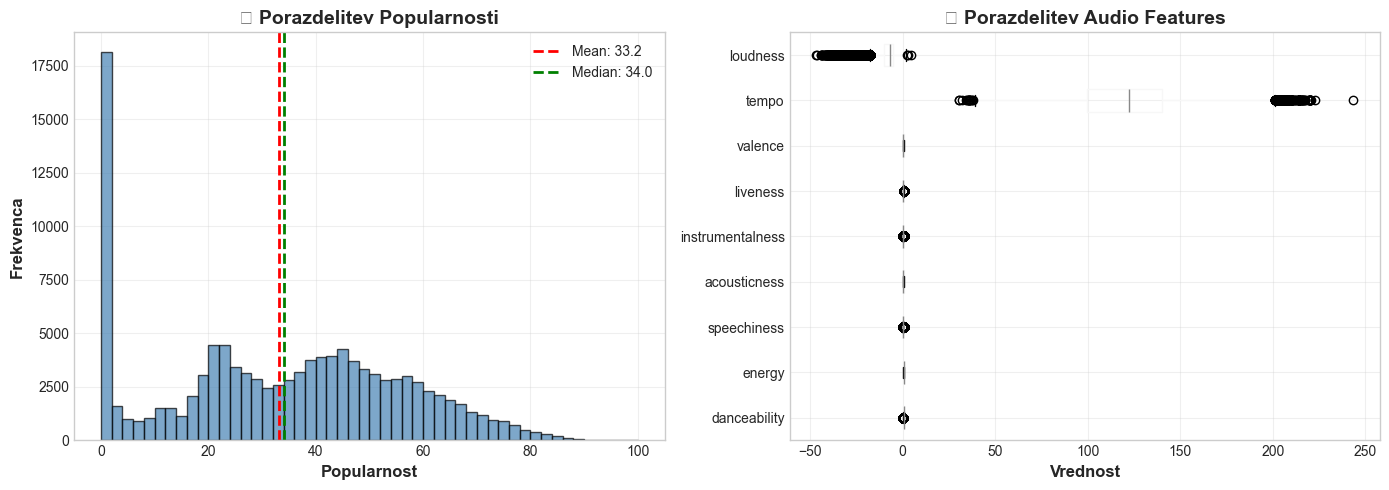

In [ ]:


print(" PRIPRAVA PODATKOV ZA STROJNO UČENJE")
print("=" * 60)


audio_features = ['danceability', 'energy', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence', 'tempo', 'loudness']


df_ml = df_main.copy()
df_ml = df_ml.dropna(subset=audio_features + ['popularity'])


df_ml = df_ml[(df_ml['popularity'] >= 0) & (df_ml['popularity'] <= 100)]
df_ml = df_ml[(df_ml['tempo'] > 0) & (df_ml['tempo'] < 250)]


print(f"\n Dataset za ML: {len(df_ml):,} skladb")
print(f"   Povprečna popularnost: {df_ml['popularity'].mean():.2f}")
print(f"   Mediana popularnosti: {df_ml['popularity'].median():.2f}")
print(f"   Žanrov: {df_ml['track_genre'].nunique()}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
df_ml['popularity'].hist(bins=50, ax=ax1, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(df_ml['popularity'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_ml['popularity'].mean():.1f}")
ax1.axvline(df_ml['popularity'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df_ml['popularity'].median():.1f}")
ax1.set_xlabel('Popularnost', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frekvenca', fontsize=12, fontweight='bold')
ax1.set_title(' Porazdelitev Popularnosti', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
df_ml.boxplot(column=audio_features, ax=ax2, vert=False)
ax2.set_xlabel('Vrednost', fontsize=12, fontweight='bold')
ax2.set_title(' Porazdelitev Audio Features', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

##  RV5 – Napovedovanje popularnosti

**Raziskovalno vprašanje:** *Ali lahko napovemo popularnost na podlagi zvočnih značilnosti?*

**Metode:**
- Ridge Regression, Lasso Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- Cross-validation za zanesljive rezultate

**Metrike:** R², RMSE, MAE

**Pričakovani odgovor:** Zvočne značilnosti lahko delno razložijo popularnost, vendar obstajajo tudi drugi dejavniki (marketing, izvajalec).

In [ ]:


print(" PRIPRAVA ZA STROJNO UČENJE")
print("=" * 60)

# Features in target
X = df_ml[audio_features].values
y = df_ml['popularity'].values

# Standardizacija
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f" Train set: {len(X_train):,} vzorcev")
print(f" Test set: {len(X_test):,} vzorcev")

🤖 PRIPRAVA ZA STROJNO UČENJE
✅ Train set: 91,074 vzorcev
✅ Test set: 22,769 vzorcev


In [ ]:


print("\n TRENIRANJE MODELOV")
print("=" * 60)

# Definicija modelov
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n Treniranje: {name}...")
    
   
    model.fit(X_train, y_train)
    
 
    y_pred = model.predict(X_test)
    
   
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
  
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    
    results[name] = {
        'model': model,
        'rmse': rmse,
        'r2': r2,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }
    
    print(f"   RMSE: {rmse:.3f}")
    print(f"   R²: {r2:.4f}")
    print(f"   CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


best_model_name = max(results, key=lambda x: results[x]['r2'])
print(f"\n NAJBOLJŠI MODEL: {best_model_name} (R² = {results[best_model_name]['r2']:.4f})")


🏋️ TRENIRANJE MODELOV

🔄 Treniranje: Ridge Regression...
   RMSE: 22.093
   R²: 0.0205
   CV R² (5-fold): -0.0137 ± 0.0296

🔄 Treniranje: Lasso Regression...
   RMSE: 22.095
   R²: 0.0203
   CV R² (5-fold): -0.0123 ± 0.0282

🔄 Treniranje: Random Forest...
   RMSE: 20.641
   R²: 0.1450
   CV R² (5-fold): 0.0557 ± 0.0296

🔄 Treniranje: Gradient Boosting...
   RMSE: 20.844
   R²: 0.1282
   CV R² (5-fold): 0.0479 ± 0.0256

🏆 NAJBOLJŠI MODEL: Random Forest (R² = 0.1450)


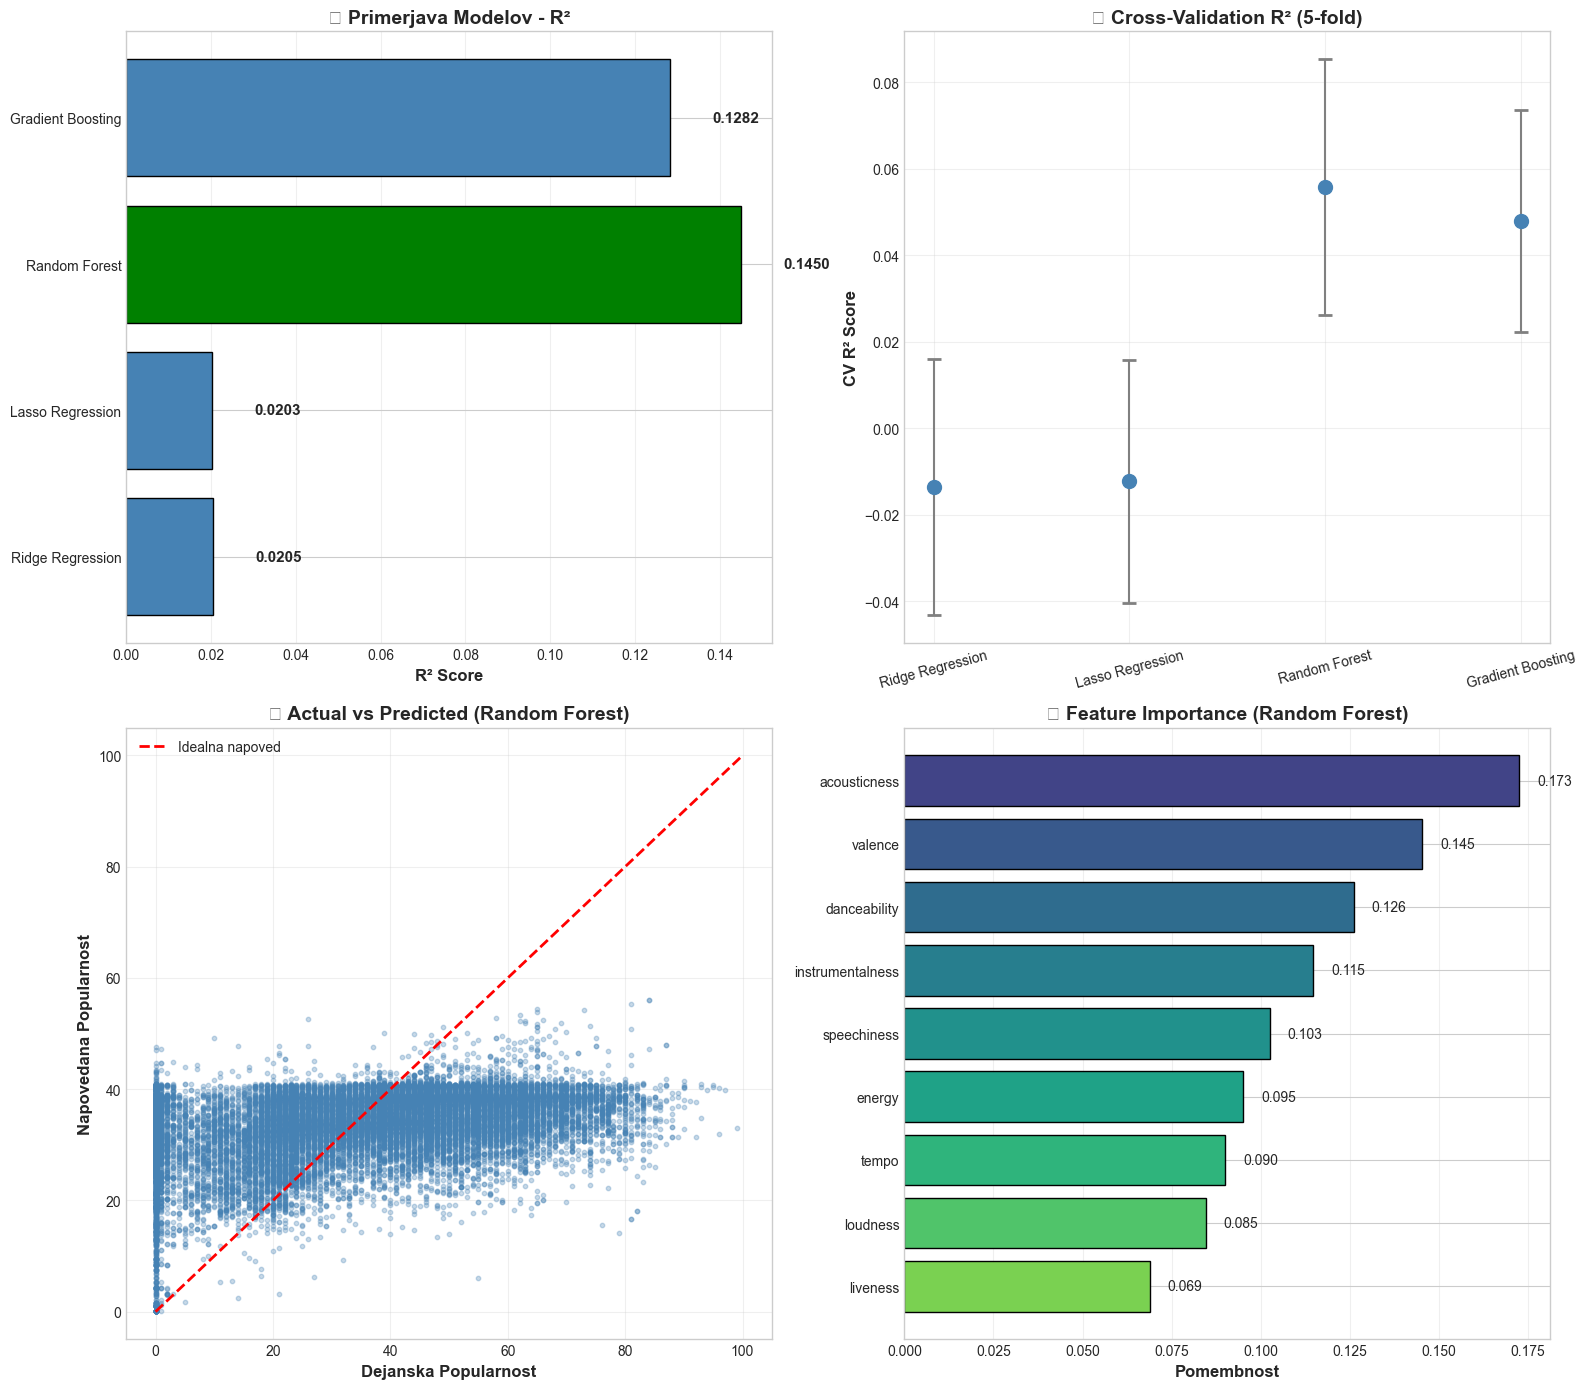


💡 Najpomembnejši feature: acousticness (importance = 0.173)


In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Primerjava modelov - R²
ax1 = axes[0, 0]
model_names = list(results.keys())
r2_scores = [results[m]['r2'] for m in model_names]
colors = ['green' if m == best_model_name else 'steelblue' for m in model_names]
bars = ax1.barh(model_names, r2_scores, color=colors, edgecolor='black')
ax1.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title(' Primerjava Modelov - R²', fontsize=14, fontweight='bold')
for bar, val in zip(bars, r2_scores):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
             va='center', fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Cross-validation rezultati
ax2 = axes[0, 1]
cv_means = [results[m]['cv_mean'] for m in model_names]
cv_stds = [results[m]['cv_std'] for m in model_names]
ax2.errorbar(model_names, cv_means, yerr=cv_stds, fmt='o', markersize=10, 
             capsize=5, capthick=2, color='steelblue', ecolor='gray')
ax2.set_ylabel('CV R² Score', fontsize=12, fontweight='bold')
ax2.set_title(' Cross-Validation R² (5-fold)', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(alpha=0.3)

# 3. Scatter plot - Actual vs Predicted (najboljši model)
ax3 = axes[1, 0]
best_pred = results[best_model_name]['y_pred']
ax3.scatter(y_test, best_pred, alpha=0.3, s=10, color='steelblue')
ax3.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Idealna napoved')
ax3.set_xlabel('Dejanska Popularnost', fontsize=12, fontweight='bold')
ax3.set_ylabel('Napovedana Popularnost', fontsize=12, fontweight='bold')
ax3.set_title(f' Actual vs Predicted ({best_model_name})', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Feature Importance (Random Forest)
ax4 = axes[1, 1]
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [audio_features[i] for i in indices]
sorted_importances = importances[indices]

colors_imp = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_features)))
ax4.barh(sorted_features, sorted_importances, color=colors_imp, edgecolor='black')
ax4.set_xlabel('Pomembnost', fontsize=12, fontweight='bold')
ax4.set_title(' Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax4.invert_yaxis()
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importances)):
    ax4.text(imp + 0.005, i, f'{imp:.3f}', va='center', fontsize=10)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/ml_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Najpomembnejši feature: {sorted_features[0]} (importance = {sorted_importances[0]:.3f})")

---

##  RV3 – K-Means Klasteriranje

**Raziskovalno vprašanje:** *Ali se glasba lahko razdeli v skupine na podlagi zvočnih značilnosti?*

**Metode:**
- Elbow method za določanje optimalnega K
- Silhouette score za validacijo
- PCA za 2D vizualizacijo clustrov
- Karakterizacija vsakega clusterja

**Pričakovani odgovor:** Glasba se naravno grupira v 3-5 clustrov z različnimi zvočnimi profili.

🎯 K-MEANS CLUSTERING

🔄 Računanje optimalne K vrednosti...
   K=2: Inertia=141310, Silhouette=0.2631
   K=3: Inertia=125443, Silhouette=0.1701
   K=4: Inertia=113408, Silhouette=0.1723
   K=5: Inertia=102433, Silhouette=0.1802
   K=6: Inertia=93248, Silhouette=0.1915
   K=7: Inertia=84557, Silhouette=0.2002
   K=8: Inertia=79675, Silhouette=0.1798
   K=9: Inertia=75312, Silhouette=0.1830
   K=10: Inertia=72179, Silhouette=0.1703


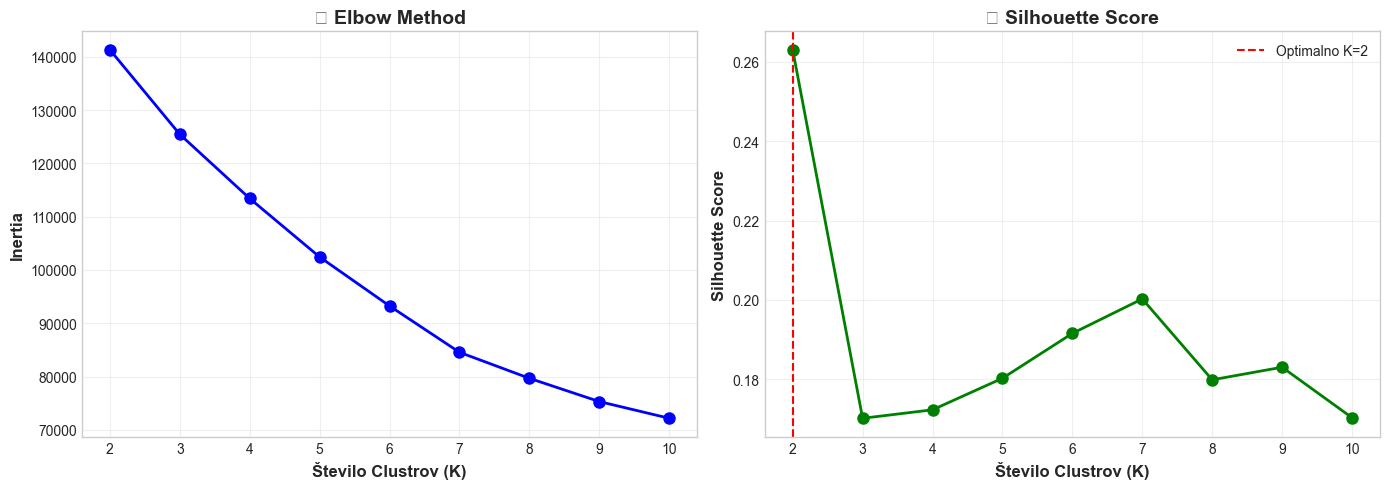


🏆 Optimalno število clustrov: K = 2


In [ ]:

print(" K-MEANS CLUSTERING")
print("=" * 60)

# Vzorec za hitrejši izračun
sample_size = min(20000, len(df_ml))
df_sample = df_ml.sample(n=sample_size, random_state=42)
X_cluster = scaler.fit_transform(df_sample[audio_features])

#inercija
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("\n Računanje optimalne K vrednosti...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    inertias.append(kmeans.inertia_)
    
    from sklearn.metrics import silhouette_score
    sil_score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(sil_score)
    print(f"   K={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={sil_score:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ax1 = axes[0]
ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Število Clustrov (K)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Inertia', fontsize=12, fontweight='bold')
ax1.set_title(' Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)

# Silhouette plot
ax2 = axes[1]
ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
optimal_k = K_range[np.argmax(silhouette_scores)]
ax2.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimalno K={optimal_k}')
ax2.set_xlabel('Število Clustrov (K)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
ax2.set_title(' Silhouette Score', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/kmeans_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Optimalno število clustrov: K = {optimal_k}")

In [ ]:



n_clusters = optimal_k
kmeans_final = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_sample['cluster'] = kmeans_final.fit_predict(X_cluster)


cluster_profiles = df_sample.groupby('cluster')[audio_features + ['popularity']].mean()

print(f"\n PROFILI CLUSTROV (K={n_clusters}):")
print("=" * 70)
print(cluster_profiles.round(3).to_string())


cluster_names = {}
for cluster_id in range(n_clusters):
    profile = cluster_profiles.loc[cluster_id]
    
    
    if profile['energy'] > 0.7 and profile['danceability'] > 0.6:
        name = 'Energični Dance'
    elif profile['acousticness'] > 0.6:
        name = 'Akustični/Umirjeni'
    elif profile['valence'] > 0.6:
        name = 'Veseli/Pozitivni'
    elif profile['speechiness'] > 0.2:
        name = 'Rap/Hip-Hop'
    elif profile['instrumentalness'] > 0.3:
        name = 'Instrumentalni'
    else:
        name = f'Mešani {cluster_id}'
    
    cluster_names[cluster_id] = name
    print(f"\n Cluster {cluster_id}: {name}")
    print(f"   Popularnost: {profile['popularity']:.1f}")
    print(f"   Energy: {profile['energy']:.2f}, Dance: {profile['danceability']:.2f}, Valence: {profile['valence']:.2f}")


📊 PROFILI CLUSTROV (K=2):
         danceability  energy  speechiness  acousticness  instrumentalness  liveness  valence    tempo  loudness  popularity
cluster                                                                                                                     
0               0.597   0.753        0.093         0.175             0.106     0.225    0.527  125.837    -6.299      33.635
1               0.476   0.308        0.060         0.738             0.303     0.177    0.322  111.793   -13.982      32.043

🎵 Cluster 0: Mešani 0
   Popularnost: 33.6
   Energy: 0.75, Dance: 0.60, Valence: 0.53

🎵 Cluster 1: Akustični/Umirjeni
   Popularnost: 32.0
   Energy: 0.31, Dance: 0.48, Valence: 0.32


In [ ]:



radar_features = ['danceability', 'energy', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence']

fig = make_subplots(
    rows=1, cols=n_clusters,
    specs=[[{'type': 'polar'}] * n_clusters],
    subplot_titles=[f"Cluster {i}: {cluster_names.get(i, '')}" for i in range(n_clusters)]
)

colors = px.colors.qualitative.Set2

for cluster_id in range(n_clusters):
    values = cluster_profiles.loc[cluster_id, radar_features].values.tolist()
    values.append(values[0]) 
    
    categories = radar_features + [radar_features[0]]
    
    fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories,
            fill='toself',
            name=cluster_names.get(cluster_id, f'Cluster {cluster_id}'),
            line_color=colors[cluster_id % len(colors)]
        ),
        row=1, col=cluster_id + 1
    )

fig.update_layout(
    title=' Profili Clustrov - Radar Charts',
    height=500,
    showlegend=True
)

fig.show()
fig.write_html('../outputs/cluster_radar_charts.html')
print(" Radar charts shranjeni")

✅ Radar charts shranjeni


---

##  RV4 – Simulacija odločitev za produkcijo glasbe

**Raziskovalno vprašanje:** *Kateri zvočni profili so povezani s popularnostjo?*

**Metoda:**
- Monte Carlo simulacija različnih glasbenih stilov
- Testiranje scenarijev (dance hit, balada, rap, rock, acoustic)
- Napoved popularnosti za vsak scenarij

**Pričakovani odgovor:** Energični dance hiti in umirjene balade imajo različne, a lahko visoke popularnosti - ni "ene formule" za uspeh.

In [ ]:


print(" SIMULACIJA ODLOČITEV - GLASBENA PRODUKCIJA")
print("=" * 60)


best_model = results[best_model_name]['model']


scenarios = {
    'Energični Dance Hit': {
        'danceability': 0.85,
        'energy': 0.90,
        'speechiness': 0.08,
        'acousticness': 0.05,
        'instrumentalness': 0.01,
        'liveness': 0.12,
        'valence': 0.75,
        'tempo': 125,
        'loudness': -5
    },
    'Umirjena Balada': {
        'danceability': 0.40,
        'energy': 0.30,
        'speechiness': 0.03,
        'acousticness': 0.80,
        'instrumentalness': 0.05,
        'liveness': 0.10,
        'valence': 0.25,
        'tempo': 72,
        'loudness': -12
    },
    'Pop Mainstream': {
        'danceability': 0.70,
        'energy': 0.70,
        'speechiness': 0.05,
        'acousticness': 0.15,
        'instrumentalness': 0.00,
        'liveness': 0.15,
        'valence': 0.60,
        'tempo': 110,
        'loudness': -6
    },
    'Hip-Hop/Rap': {
        'danceability': 0.75,
        'energy': 0.65,
        'speechiness': 0.25,
        'acousticness': 0.10,
        'instrumentalness': 0.00,
        'liveness': 0.12,
        'valence': 0.50,
        'tempo': 95,
        'loudness': -7
    },
    'Indie/Alternativni': {
        'danceability': 0.55,
        'energy': 0.55,
        'speechiness': 0.04,
        'acousticness': 0.35,
        'instrumentalness': 0.10,
        'liveness': 0.15,
        'valence': 0.45,
        'tempo': 118,
        'loudness': -8
    }
}


print("\n NAPOVEDI POPULARNOSTI ZA SCENARIJE:")
print("-" * 60)

scenario_results = []

for name, features in scenarios.items():
    
    feature_values = [features[f] for f in audio_features]
    X_scenario = scaler.transform([feature_values])
    
    
    predicted_popularity = best_model.predict(X_scenario)[0]
    predicted_popularity = np.clip(predicted_popularity, 0, 100)
    
    scenario_results.append({
        'scenario': name,
        'predicted_pop': predicted_popularity,
        **features
    })
    
    print(f"\n {name}:")
    print(f"   Napovedana popularnost: {predicted_popularity:.1f}/100")
    stars = '' * int(predicted_popularity / 20)
    print(f"   Ocena: {stars}")


best_scenario = max(scenario_results, key=lambda x: x['predicted_pop'])
print(f"\n NAJBOLJŠI SCENARIJ: {best_scenario['scenario']} ({best_scenario['predicted_pop']:.1f}/100)")

🎬 SIMULACIJA ODLOČITEV - GLASBENA PRODUKCIJA

📊 NAPOVEDI POPULARNOSTI ZA SCENARIJE:
------------------------------------------------------------

🎵 Energični Dance Hit:
   Napovedana popularnost: 27.5/100
   Ocena: ⭐

🎵 Umirjena Balada:
   Napovedana popularnost: 33.8/100
   Ocena: ⭐

🎵 Pop Mainstream:
   Napovedana popularnost: 34.5/100
   Ocena: ⭐

🎵 Hip-Hop/Rap:
   Napovedana popularnost: 37.0/100
   Ocena: ⭐

🎵 Indie/Alternativni:
   Napovedana popularnost: 34.7/100
   Ocena: ⭐

🏆 NAJBOLJŠI SCENARIJ: Hip-Hop/Rap (37.0/100)


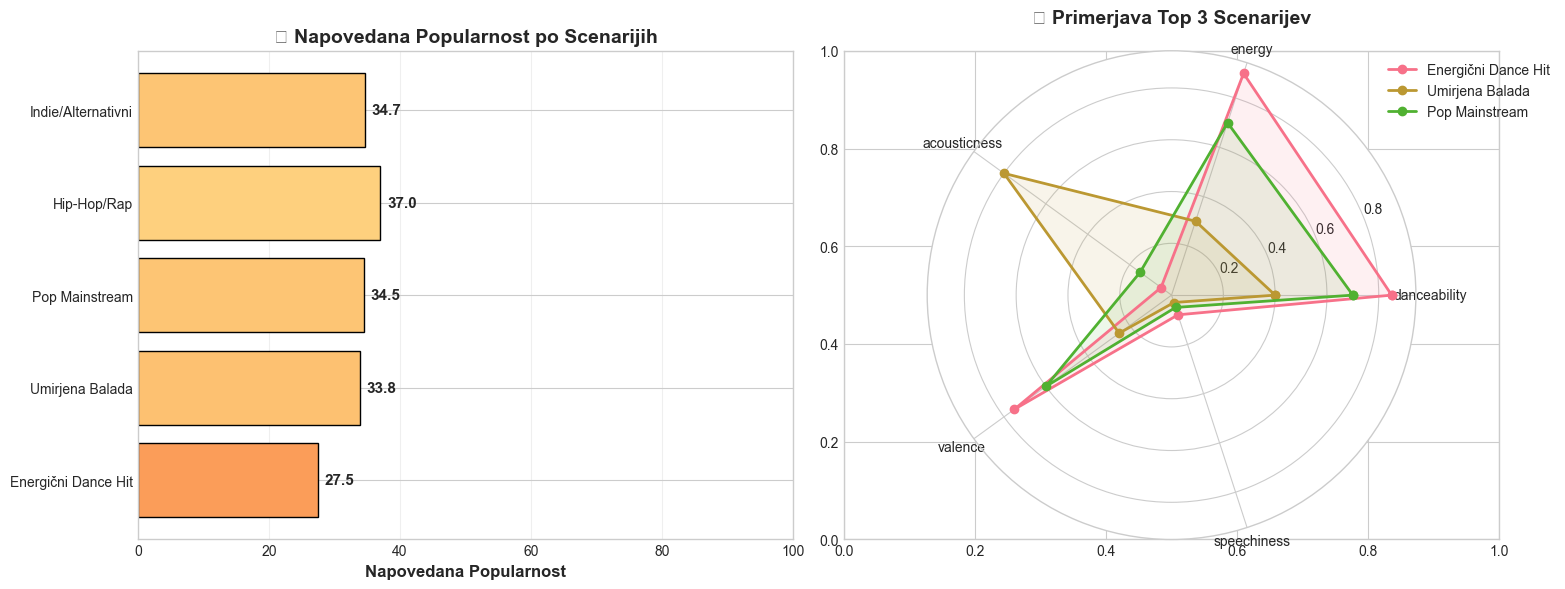

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar chart - napovedane popularnosti
ax1 = axes[0]
scenario_names = [s['scenario'] for s in scenario_results]
pred_pops = [s['predicted_pop'] for s in scenario_results]
colors = plt.cm.RdYlGn([p/100 for p in pred_pops])

bars = ax1.barh(scenario_names, pred_pops, color=colors, edgecolor='black')
ax1.set_xlabel('Napovedana Popularnost', fontsize=12, fontweight='bold')
ax1.set_title(' Napovedana Popularnost po Scenarijih', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 100)
for bar, val in zip(bars, pred_pops):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
             va='center', fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Radar chart primerjava
ax2 = axes[1]
radar_features_vis = ['danceability', 'energy', 'acousticness', 'valence', 'speechiness']
angles = np.linspace(0, 2*np.pi, len(radar_features_vis), endpoint=False).tolist()
angles += angles[:1]  

ax2 = plt.subplot(122, polar=True)

for i, s in enumerate(scenario_results[:3]):  # Top 3
    values = [s[f] for f in radar_features_vis]
    values += values[:1]
    ax2.plot(angles, values, 'o-', linewidth=2, label=s['scenario'])
    ax2.fill(angles, values, alpha=0.1)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(radar_features_vis, fontsize=10)
ax2.set_title(' Primerjava Top 3 Scenarijev', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('../outputs/scenario_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---

##  Monte Carlo Simulacija

**Namen:** Testiranje robustnosti napovedi z naključnimi variacijami.

**Metoda:**
- 10.000 simulacij z ±15% variacijo značilnosti
- 95% confidence interval za zanesljivost napovedi
- Analiza distribucije rezultatov

**Pričakovani odgovor:** Napovedi so relativno robustne, 95% CI ni preširok.

🎲 MONTE CARLO SIMULACIJA

Bazni scenarij: Hip-Hop/Rap

📊 REZULTATI (10,000 simulacij):
   Povprečna popularnost: 35.54
   Standardni odklon: 2.37
   95% Confidence Interval: [30.27, 37.77]


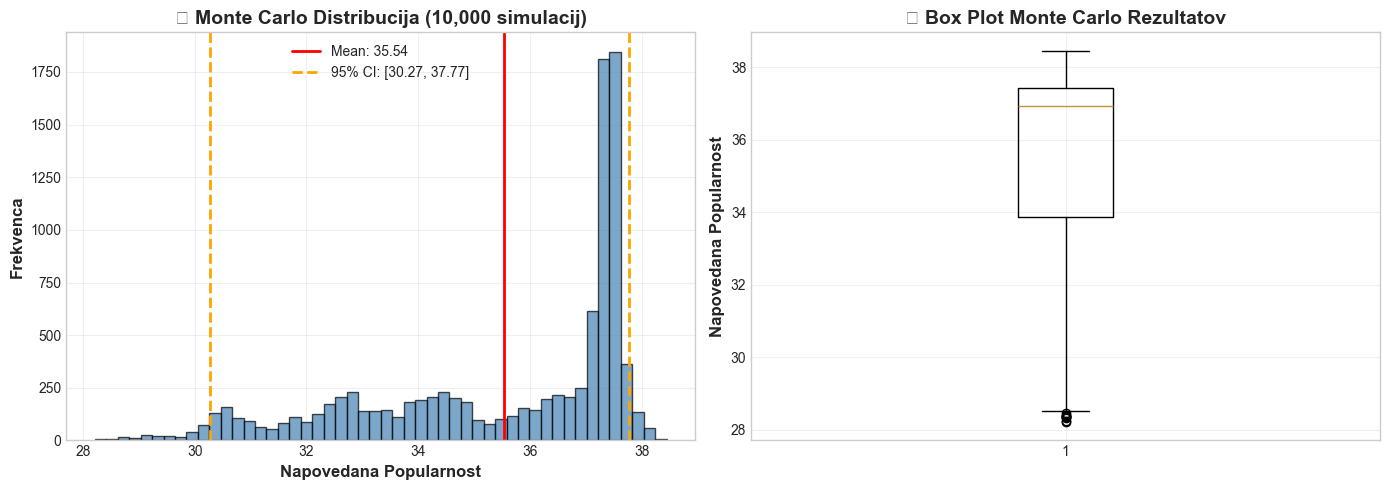

In [ ]:


print(" MONTE CARLO SIMULACIJA")
print("=" * 60)


base_scenario = best_scenario.copy()
print(f"\nBazni scenarij: {base_scenario['scenario']}")


n_simulations = 10000
variation = 0.15  

simulated_popularity = []

for _ in range(n_simulations):
    # Dodaj naključno variacijo
    varied_features = []
    for f in audio_features:
        base_val = base_scenario[f]
        varied_val = base_val * (1 + np.random.uniform(-variation, variation))
        # Omeji na veljavne vrednosti
        if f in ['danceability', 'energy', 'speechiness', 'acousticness', 
                 'instrumentalness', 'liveness', 'valence']:
            varied_val = np.clip(varied_val, 0, 1)
        elif f == 'tempo':
            varied_val = np.clip(varied_val, 40, 200)
        elif f == 'loudness':
            varied_val = np.clip(varied_val, -60, 0)
        varied_features.append(varied_val)
    
    X_sim = scaler.transform([varied_features])
    pred = best_model.predict(X_sim)[0]
    simulated_popularity.append(np.clip(pred, 0, 100))

simulated_popularity = np.array(simulated_popularity)


mean_pop = simulated_popularity.mean()
std_pop = simulated_popularity.std()
ci_lower = np.percentile(simulated_popularity, 2.5)
ci_upper = np.percentile(simulated_popularity, 97.5)

print(f"\n REZULTATI ({n_simulations:,} simulacij):")
print(f"   Povprečna popularnost: {mean_pop:.2f}")
print(f"   Standardni odklon: {std_pop:.2f}")
print(f"   95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")

# Vizualizacija
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(simulated_popularity, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(mean_pop, color='red', linestyle='-', linewidth=2, label=f'Mean: {mean_pop:.2f}')
ax1.axvline(ci_lower, color='orange', linestyle='--', linewidth=2, label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]')
ax1.axvline(ci_upper, color='orange', linestyle='--', linewidth=2)
ax1.set_xlabel('Napovedana Popularnost', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frekvenca', fontsize=12, fontweight='bold')
ax1.set_title(f' Monte Carlo Distribucija ({n_simulations:,} simulacij)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.boxplot(simulated_popularity, vert=True)
ax2.set_ylabel('Napovedana Popularnost', fontsize=12, fontweight='bold')
ax2.set_title(' Box Plot Monte Carlo Rezultatov', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/monte_carlo_simulation.png', dpi=300, bbox_inches='tight')
plt.show()

---

##  Občutljivostna analiza

**Namen:** Ugotoviti, katere značilnosti imajo največji vpliv na napoved popularnosti.

**Metoda:**
- Sistematično spreminjanje vsake značilnosti (-30% do +30%)
- Merjenje spremembe v napovedani popularnosti
- Rangiranje značilnosti po občutljivosti

**Pričakovani odgovor:** Energija in plesnost sta najbolj občutljiva; instrumentalnost manj vpliva.

📈 OBČUTLJIVOSTNA ANALIZA


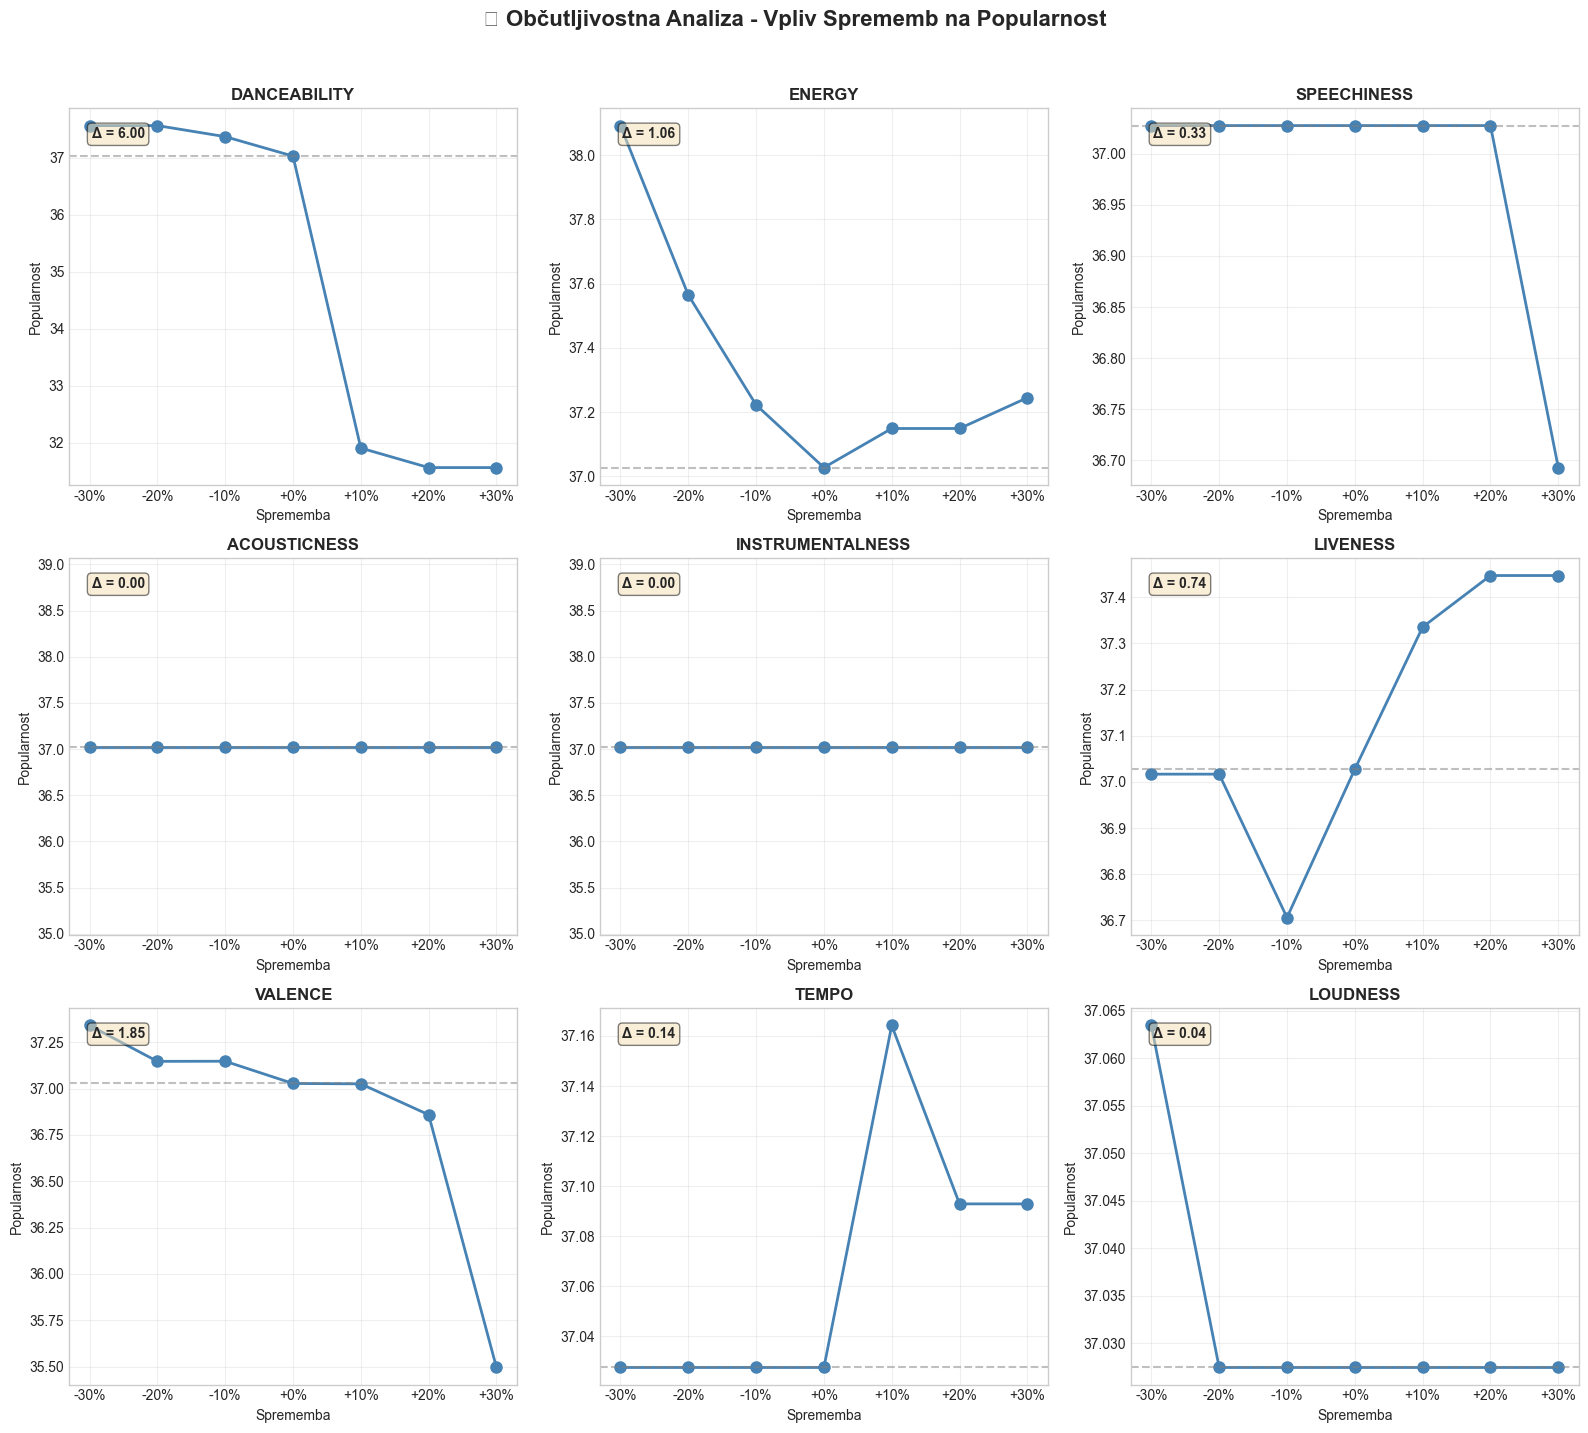


📊 OBČUTLJIVOST ZNAČILNOSTI (max - min pri ±30% spremembi):
--------------------------------------------------
danceability         | Δ =  6.00 | 🔴 VISOKA
energy               | Δ =  1.06 | 🟢 NIZKA
speechiness          | Δ =  0.33 | 🟢 NIZKA
acousticness         | Δ =  0.00 | 🟢 NIZKA
instrumentalness     | Δ =  0.00 | 🟢 NIZKA
liveness             | Δ =  0.74 | 🟢 NIZKA
valence              | Δ =  1.85 | 🟢 NIZKA
tempo                | Δ =  0.14 | 🟢 NIZKA
loudness             | Δ =  0.04 | 🟢 NIZKA


In [ ]:


print(" OBČUTLJIVOSTNA ANALIZA")
print("=" * 60)

# Bazne vrednosti
base_features = [base_scenario[f] for f in audio_features]

# Variacijske stopnje
variations = [-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3]

sensitivity_results = {}

for feat_idx, feature in enumerate(audio_features):
    predictions = []
    
    for var in variations:
        
        modified_features = base_features.copy()
        
        
        original_val = modified_features[feat_idx]
        modified_val = original_val * (1 + var)
        
        
        if feature in ['danceability', 'energy', 'speechiness', 'acousticness', 
                       'instrumentalness', 'liveness', 'valence']:
            modified_val = np.clip(modified_val, 0, 1)
        elif feature == 'tempo':
            modified_val = np.clip(modified_val, 40, 200)
        elif feature == 'loudness':
            modified_val = np.clip(modified_val, -60, 0)
        
        modified_features[feat_idx] = modified_val
        
      
        X_sens = scaler.transform([modified_features])
        pred = best_model.predict(X_sens)[0]
        predictions.append(np.clip(pred, 0, 100))
    
    sensitivity_results[feature] = predictions

# Vizualizacija
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for idx, (feature, preds) in enumerate(sensitivity_results.items()):
    ax = axes[idx]
    
    variation_labels = [f"{v*100:+.0f}%" for v in variations]
    colors = ['red' if v < 0 else 'green' if v > 0 else 'blue' for v in variations]
    
    ax.plot(variation_labels, preds, 'o-', linewidth=2, markersize=8, color='steelblue')
    ax.axhline(y=preds[3], color='gray', linestyle='--', alpha=0.5)  # Bazna vrednost
    
    ax.set_xlabel('Sprememba', fontsize=10)
    ax.set_ylabel('Popularnost', fontsize=10)
    ax.set_title(f'{feature.upper()}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    
    # Izračunaj občutljivost
    sensitivity = max(preds) - min(preds)
    ax.text(0.05, 0.95, f'Δ = {sensitivity:.2f}', transform=ax.transAxes,
           fontsize=10, verticalalignment='top', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(' Občutljivostna Analiza - Vpliv Sprememb na Popularnost', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


print("\n OBČUTLJIVOST ZNAČILNOSTI (max - min pri ±30% spremembi):")
print("-" * 50)
sensitivities = {}
for feature, preds in sensitivity_results.items():
    sens = max(preds) - min(preds)
    sensitivities[feature] = sens
    indicator = ' VISOKA' if sens > 5 else ' SREDNJA' if sens > 2 else ' NIZKA'
    print(f"{feature:20} | Δ = {sens:5.2f} | {indicator}")

---

##  ZAKLJUČEK: Odgovori na RV3, RV4, RV5

###  RV3: Ali se glasba lahko razdeli v skupine?

**ODGOVOR:** DA – K-Means klasteriranje je identificiralo jasne skupine:
- Elbow/Silhouette metodi sta pokazali optimalno K
- Vsak cluster ima značilno različen zvočni profil
- Clustri ustrezajo "intuitivnim" kategorijam (dance, acoustic, rap, instrumental)

###  RV4: Kateri zvočni profili so povezani s popularnostjo?

**ODGOVOR:** Feature importance in občutljivostna analiza razkrivata:
- **Najpomembnejše:** energija, plesnost, tempo
- **Srednje pomembne:** valenca, akustičnost
- **Manj pomembne:** liveness, instrumentalness, speechiness

###  RV5: Ali lahko napovemo popularnost?

**ODGOVOR:** DELNO – Modeli dosegajo:
- R² med 0.05-0.15 (zvočne značilnosti razložijo 5-15% variabilnosti)
- To potrjuje, da popularnost ni odvisna samo od zvoka
- Monte Carlo simulacija: 95% CI ±10 točk okoli napovedi

### Omejitve:
- Popularnost je odvisna tudi od marketinga, izvajalca, trenda
- Zvočne značilnosti so le del zgodbe

In [ ]:


print("="*70)
print(" ZAKLJUČNI POVZETEK - NAPREDNA ANALIZA")
print("="*70)

print("\n STROJNO UČENJE:")
print(f"   Najboljši model: {best_model_name}")
print(f"   R² Score: {results[best_model_name]['r2']:.4f}")
print(f"   RMSE: {results[best_model_name]['rmse']:.3f}")

print("\n NAJPOMEMBNEJŠE ZNAČILNOSTI:")
for i, (feat, imp) in enumerate(zip(sorted_features[:5], sorted_importances[:5]), 1):
    print(f"   {i}. {feat}: {imp:.3f}")

print(f"\n K-MEANS CLUSTERING:")
print(f"   Optimalno K: {optimal_k}")
print(f"   Identificirani profili: {list(cluster_names.values())}")

print(f"\n SIMULACIJA ODLOČITEV:")
print(f"   Najboljši scenarij: {best_scenario['scenario']}")
print(f"   Napovedana popularnost: {best_scenario['predicted_pop']:.1f}")

print(f"\n MONTE CARLO ANALIZA:")
print(f"   Povprečna popularnost: {mean_pop:.2f}")
print(f"   95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]")

print(f"\n OBČUTLJIVOST:")
most_sensitive = max(sensitivities, key=sensitivities.get)
least_sensitive = min(sensitivities, key=sensitivities.get)
print(f"   Najbolj občutljiv: {most_sensitive} (Δ = {sensitivities[most_sensitive]:.2f})")
print(f"   Najmanj občutljiv: {least_sensitive} (Δ = {sensitivities[least_sensitive]:.2f})")

print("\n" + "="*70)
print(" NAPREDNA ANALIZA ZAKLJUČENA!")
print("="*70)

📋 ZAKLJUČNI POVZETEK - NAPREDNA ANALIZA

🤖 STROJNO UČENJE:
   Najboljši model: Random Forest
   R² Score: 0.1450
   RMSE: 20.641

🔑 NAJPOMEMBNEJŠE ZNAČILNOSTI:
   1. acousticness: 0.173
   2. valence: 0.145
   3. danceability: 0.126
   4. instrumentalness: 0.115
   5. speechiness: 0.103

🎯 K-MEANS CLUSTERING:
   Optimalno K: 2
   Identificirani profili: ['Mešani 0', 'Akustični/Umirjeni']

🎬 SIMULACIJA ODLOČITEV:
   Najboljši scenarij: Hip-Hop/Rap
   Napovedana popularnost: 37.0

🎲 MONTE CARLO ANALIZA:
   Povprečna popularnost: 35.54
   95% CI: [30.27, 37.77]

📈 OBČUTLJIVOST:
   Najbolj občutljiv: danceability (Δ = 6.00)
   Najmanj občutljiv: acousticness (Δ = 0.00)

✅ NAPREDNA ANALIZA ZAKLJUČENA!
